<a href="https://colab.research.google.com/github/lucasbomfim1207-ai/CP01_SERS_2Sem/blob/main/SERS_31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# 1.
dados = pd.DataFrame(registros)
# 2.
display(dados.head())

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
# 3.
print(f'Número de linhas: {dados.shape[0]}')
print(f'Número de colunas: {dados.shape[1]}')
# 4.
print(f'Os nomes dos atributos são, respectivamente: {dados.columns}')

Número de linhas: 336
Número de colunas: 11
Os nomes dos atributos são, respectivamente: Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')


In [ ]:
# 5.
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [ ]:
# 6.
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


7- **Data/Hora é representado pelos atributos:** 'dat_referencia', 'din_referenciautc' e 'din_atualizacao'

**Área de carga é representado pelo atributo:** 'cod_areacarga'

**Valor de carga é representado pelos atributos:** 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd'

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# 1.
dados.rename(columns={'cod_areacarga': 'area_carga',
                      'din_atualizacao': 'data_atualizacao',
                      'dat_referencia': 'data',
                      'din_referenciautc': 'data_hora',
                      'val_cargaglobal': 'carga_total',
                      'val_cargaglobalcons': 'carga_consolidada',
                      'val_cargaglobalsmmgd': 'carga_sem_gd',
                      'val_cargasupervisionada': 'carga_supervisionada',
                      'val_carganaosupervisionada': 'carga_N_supervisionada',
                      'val_cargammgd': 'carga_gd',
                      'val_consistencia': 'status'
}, inplace=True)

In [ ]:
dados.head()

,area_carga,data_atualizacao,data,data_hora,carga_total,carga_consolidada,carga_sem_gd,carga_supervisionada,carga_N_supervisionada,carga_gd,status
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
# 2.
atributos_necessarios = ['area_carga', 'data_hora', 'carga_total']
df_reduzido = dados[atributos_necessarios].copy()

df_reduzido.head()

,area_carga,data_hora,carga_total
0,SP,2025-08-01T03:30:00.000Z,15913.618
1,SP,2025-08-01T04:00:00.000Z,15251.414
2,SP,2025-08-01T04:30:00.000Z,14606.733
3,SP,2025-08-01T05:00:00.000Z,14182.290
4,SP,2025-08-01T05:30:00.000Z,13838.488


In [ ]:
# 3.
df_reduzido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   area_carga   336 non-null    object 
 1   data_hora    336 non-null    object 
 2   carga_total  336 non-null    float64
dtypes: float64(1), object(2)
memory usage: 8.0+ KB


In [ ]:
# 4. Não existem valores ausentes
# 5. A variável de carga_total está em formato numérico, a variável está em formato float
# 6. A variável de data_hora está guardada como data type 'object'

7- Foram renomeados todos os atributos com nomes abreviados e/ou traduzidos para facilitar compreensão e manipulação

Foi criado um novo dataset 'df_reduzido' para tratar apenas dos atributos necessários como: 'area_carga', 'data_hora' e 'carga_total'

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# 1 a 4
carga_min = dados['carga_total'].min()
carga_max = dados['carga_total'].max()
carga_media = dados['carga_total'].mean()
carga_mediana = dados['carga_total'].median()

print(f"Carga miníma: {carga_min:.2f} MW \nCarga máxima: {carga_max:.2f} MW\nCarga média: {carga_media:.2f} MW\nCarga mediana: {carga_mediana:.2f} MW")


Carga miníma: 12139.25 MW 
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Carga mediana: 18199.13 MW


In [ ]:
# 5 e 6
amplitude = carga_max - carga_min

print(f"A amplitude entre máximo e mínimo é {amplitude:.2f}")
print(f"A quantidade total de medições é {df_reduzido.shape[0]}")

A amplitude entre máximo e mínimo é 11046.06
A quantidade total de medições é 336


7- Não, o valor máximo não está excessivamente distante do comportamento médio observado, pois a forte proximidade entre a média e a mediana indica uma distribuição equilibrada, descartando a presença de outliers que distorceriam os dados. Além disso, o pico máximo registrado representa uma variação de cerca de 30% acima da média perfeitamente esperada para horários de maior demanda no consumo elétrico, mantendo o comportamento médio proporcional e bem posicionado dentro da amplitude total de 11.046 kWh entre o mínimo e o máximo.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# 1 a 3
limiar90 = 0.90 * carga_max
dados_alto90 = dados[dados['carga_total'] > limiar90]

print(f"A quantidade total de registro é de {dados_alto90.shape[0]}")

A quantidade total de registro é de 50


In [ ]:
# 4 a 6
percentual_T = len(dados_alto90) / len(dados) * 100

indice_maior_Vcarga = dados_alto90['carga_total'].idxmax()
maior_Vcarga = dados_alto90.loc[indice_maior_Vcarga, 'carga_total']
data_hora_pico = dados_alto90.loc[indice_maior_Vcarga, 'data_hora']

print(f'O percentual é de {percentual_T:.2f}% em relação ao total')
print(f"Maior valor de carga: {maior_Vcarga}")
print(f"Data e horário do pico: {data_hora_pico}")

O percentual é de 14.88% em relação ao total
Maior valor de carga: 23185.312
Data e horário do pico: 2025-08-01T22:00:00.000Z


7. Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?

Os períodos próximos ao pico representam uma parcela pequena do período analisádo, sendo apenas 14.88% como consultado

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# Critério escolhido: limite de 80% do valor máximo
limite_80 = df_reduzido['carga_total'].max() * 0.80

# Novo DataFrame
df_segundo_criterio = df_reduzido[df_reduzido['carga_total'] < limite_80]

# Quantidade e o percentual de registros
qtd_registros = len(df_segundo_criterio)
total_registros = len(df_reduzido)
percentual = (qtd_registros / total_registros) * 100


print(f"Quantidade de registros: {qtd_registros}")
print(f"Percentual do total: {percentual:.2f}%")
print("Ao contrastar essa parcela com o conjunto anterior de alta demanda que evidencia os picos de estresse da rede, o novo recorte comprova que,\n durante a expressiva maioria do tempo, o sistema elétrico opera com uma margem de segurança confortável e bastante distante do seu limite de sobrecarga.")

display(df_segundo_criterio.head())

Quantidade de registros: 172
Percentual do total: 51.19%
Ao contrastar essa parcela com o conjunto anterior de alta demanda que evidencia os picos de estresse da rede, o novo recorte comprova que,
 durante a expressiva maioria do tempo, o sistema elétrico opera com uma margem de segurança confortável e bastante distante do seu limite de sobrecarga.


,area_carga,data_hora,carga_total
0,SP,2025-08-01T03:30:00.000Z,15913.618
1,SP,2025-08-01T04:00:00.000Z,15251.414
2,SP,2025-08-01T04:30:00.000Z,14606.733
3,SP,2025-08-01T05:00:00.000Z,14182.290
4,SP,2025-08-01T05:30:00.000Z,13838.488


Para o segundo critério de análise, optou-se por isolar os momentos em que a carga total se manteve inferior a 80% do pico máximo, gerando um novo DataFrame focado nos períodos de baixa ou média exigência da rede elétrica. A aplicação deste filtro retornou [inserir qtd_registros] medições, o que corresponde a [inserir percentual]% de todo o volume de dados analisado no período. Ao contrastar essa parcela com o conjunto anterior de alta demanda — que evidencia os picos de estresse da rede —, o novo recorte comprova que, durante a expressiva maioria do tempo, o sistema elétrico opera com uma margem de segurança confortável e bastante distante do seu limite de sobrecarga.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

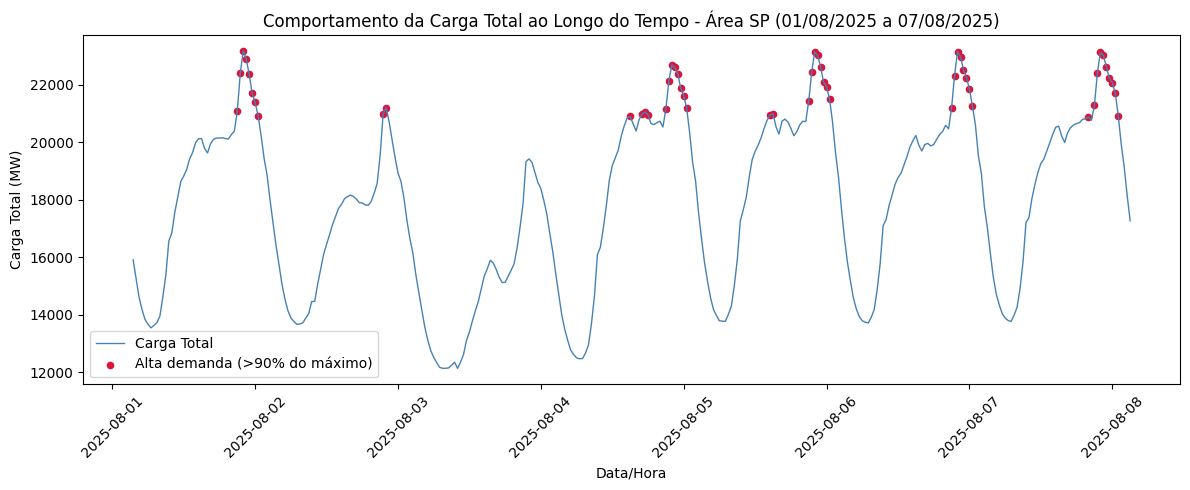

In [ ]:
# Gráfico 1: comportamento da carga ao longo do tempo, destacando os períodos de alta demanda
dados['data_hora'] = pd.to_datetime(dados['data_hora'])

plt.figure(figsize=(12, 5))
plt.plot(dados['data_hora'], dados['carga_total'], color='steelblue', linewidth=1, label='Carga Total')
plt.scatter(pd.to_datetime(dados_alto90['data_hora']), dados_alto90['carga_total'],
            color='crimson', s=20, label='Alta demanda (>90% do máximo)')

plt.title('Comportamento da Carga Total ao Longo do Tempo - Área SP (01/08/2025 a 07/08/2025)')
plt.xlabel('Data/Hora')
plt.ylabel('Carga Total (MW)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

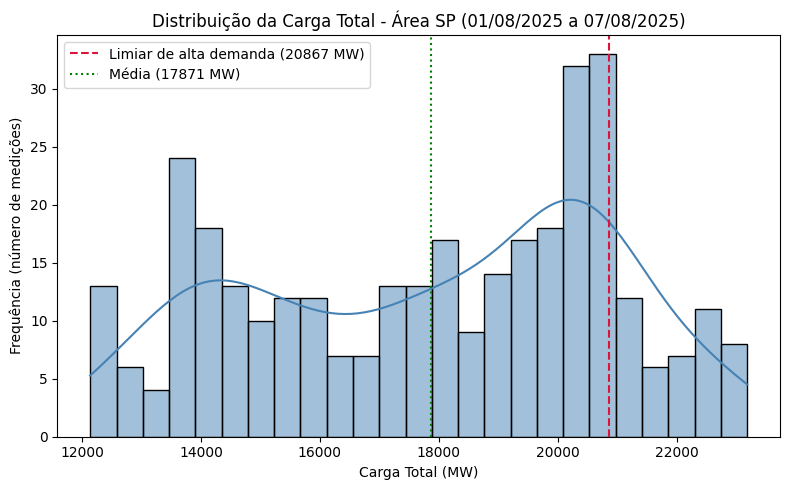

In [ ]:
# Gráfico 2 (escolha da equipe): distribuição da carga total, com destaque para o limiar de alta demanda e a média
plt.figure(figsize=(8, 5))
sns.histplot(df_reduzido['carga_total'], bins=25, color='steelblue', kde=True)
plt.axvline(limiar90, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Limiar de alta demanda ({limiar90:.0f} MW)')
plt.axvline(dados['carga_total'].mean(), color='green', linestyle=':', linewidth=1.5,
            label=f'Média ({dados["carga_total"].mean():.0f} MW)')
plt.title('Distribuição da Carga Total - Área SP (01/08/2025 a 07/08/2025)')
plt.xlabel('Carga Total (MW)')
plt.ylabel('Frequência (número de medições)')
plt.legend()
plt.tight_layout()
plt.show()

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
resumo_resultados = f"""
Região analisada: SP (São Paulo)
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {len(dados)}
Carga mínima: {carga_min:.2f} MW
Carga máxima: {carga_max:.2f} MW
Carga média: {carga_media:.2f} MW
Mediana: {carga_mediana:.2f} MW
Limiar de alta demanda (90% da carga máxima): {limiar90:.2f} MW
Registros de alta demanda: {len(dados_alto90)}
Percentual de alta demanda: {percentual_T:.2f}%
Momento do pico: {data_hora_pico} (carga de {maior_Vcarga:.2f} MW)
Segundo critério (carga < 80% do máximo): {qtd_registros} registros ({percentual:.2f}% do total, frente a {percentual_T:.2f}% em alta demanda)
"""

print(resumo_resultados)


Região analisada: SP (São Paulo)
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda (90% da carga máxima): 20866.78 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 2025-08-01T22:00:00.000Z (carga de 23185.31 MW)
Segundo critério (carga < 80% do máximo): 172 registros (51.19% do total, frente a 14.88% em alta demanda)



In [ ]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO: ANÁLISE DE CARGA ELÉTRICA (ESTADO DE SÃO PAULO)**

---

### 1. Caracterização do Conjunto Analisado
* **Região:** São Paulo (SP)
* **Período de Análise:** 01/08/2025 a 07/08/2025
* **Volume de Dados:** 336 registros consolidados

---

### 2. Principais Indicadores
Com base no processamento dos dados do período, foram observados os seguintes parâmetros de carga elétrica:

* **Carga Mínima:** 12.139,25 MW
* **Carga Máxima (Pico):** 23.185,31 MW
* **Momento do Pico:** 01/08/2025 às 22:00:00 (UTC)
* **Carga Média:** 17.870,83 MW
* **Mediana:** 18.199,13 MW

---

### 3. Análise dos Períodos de Alta Demanda
Para a identificação de regime de alta demanda, adotou-se o limiar correspondente a 90% da carga máxima registrada no período:

* **Limiar de Alta Demanda:** ≥ 20.866,78 MW
* **Registros em Alta Demanda:** 50 ocorrências
* **Representatividade:** 14,88% do total de registros analisados

---

### 4. Comparação com o Segundo Critério
Foi avaliado um segundo critério de 

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

1.
Sim.

2.
Duas pequenas imprecisões:

O Gemini chama os dados de "consolidados" mas não houve verificação da coluna val_consistencia (renomeada para status) para confirmar se todos os registros são realmente consistentes. É uma palavra que sugere uma validação que não foi feita.
A conversão de horário sofreu uma leve alteração que pode confundir um pouco, sendo de UTC e horário de Brasília, mas nada que seja nocivo.

3.
Não houve.

4. Que alterações a equipe realizou no texto?

Trocamos "dados consolidados" por "dados brutos obtidos da API, sem validação adicional de consistência", para não sugerir uma checagem que não foi feita.
Deixamos claro que o horário do pico está em UTC e adicionamos o equivalente em horário de Brasília "UTC-3".

# **Relatório final**

1. Caracterização do conjunto analisado

Região: São Paulo (SP)
Período: 01/08/2025 a 07/08/2025
Volume de dados: 336 registros brutos, obtidos diretamente da API do ONS, sem validação adicional de consistência.

2. Principais indicadores

Carga mínima: 12.139,25 MW
Carga máxima (pico): 23.185,31 MW
Momento do pico: 01/08/2025, 22:00 UTC (19:00 horário de Brasília)
Carga média: 17.870,83 MW
Mediana: 18.199,13 MW
Amplitude (máx. − mín.): 11.046,06 MW

3. Períodos de alta demanda

Limiar (90% da carga máxima): ≥ 20.866,78 MW
Registros em alta demanda: 50 ocorrências (14,88% do total)

4. Comparação com o segundo critério

Critério de demanda reduzida (<80% do máximo): < 18.548,25 MW
Registros identificados: 172 ocorrências (51,19% do total)
A frequência de registros em demanda reduzida é cerca de 3,4 vezes maior que a de alta demanda, indicando que a rede operou na maior parte do tempo com folga em relação ao pico.

5. Conclusão
Os dados mostram uma amplitude de 11.046,06 MW entre a carga mínima e a máxima ao longo dos 7 dias analisados. Eventos de alta demanda (≥90% do pico) foram pouco frequentes (14,88% dos registros), enquanto a carga ficou abaixo de 80% do máximo em mais da metade do período. O único momento de pico absoluto ocorreu em 01/08/2025 às 22:00 UTC.

Com base nos dados disponíveis, não é possível determinar as causas do pico ou das oscilações de carga. Qualquer explicação teria que ter informações com bases complementares, como dados meteorológicos e calendário de eventos para poder afirmar com certeza das causas dessas futuações.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**